## 0. 실험 목적

기본 CAM은 `Conv5 -> GAP -> FC` 구조에서만 FC weight가 Conv5 channel과 직접 대응 ->  `FC weight[class, channel]`를 Conv5 feature map의 channel별 중요도로 해석 O  

`Conv5 -> GAP -> FC(2048->2048) -> ReLU -> FC(2048->120)` (multi FC)구조에서는 마지막 FC weight가 Conv5 channel이 아니라 hidden feature에 연결 -> Conv5 feature map에 직접 곱하면 이상한 무언가가 됨  

Grad-CAM은 특정 class score가 target layer feature map에 대해 가지는 gradient를 사용하므로, FC head가 단순 FC이든 Multi-FC이든 같은 방식으로 적용할 수 있습니다.

In [ ]:
import csv
import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from PIL import ImageFile
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import ResNet50_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Jupyter를 GoingDeeper에서 열어도, Sp01 안에서 열어도 같은 경로를 쓰도록 처리합니다.
cwd = Path.cwd()
SP01_DIR = cwd if cwd.name == "Sp01" else cwd / "Sp01"
if not SP01_DIR.exists():
    SP01_DIR = Path("Sp01")

DATA_ROOT = Path.home() / "datasets" / "stanfordimagenetdogs"
DOGS_DIR = SP01_DIR / "stanford_dogs"
CHECKPOINT_DIR = SP01_DIR / "checkpoints"
HISTORY_DIR = SP01_DIR / "histories"
OUTPUT_DIR = SP01_DIR / "outputs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASIC_CKPT = CHECKPOINT_DIR / "exp_basic_cam_model.pt"
MULTI_FC_CKPT = CHECKPOINT_DIR / "exp_multi_fc_model.pt"
BASIC_HISTORY_CSV = HISTORY_DIR / "exp_basic_cam_history.csv"
MULTI_FC_HISTORY_CSV = HISTORY_DIR / "exp_multi_fc_history.csv"
COMPARISON_PATH = OUTPUT_DIR / "exp_cam_gradcam_comparison.png"

IMAGE_SIZE = 224
BATCH_SIZE = 12
NUM_CLASSES = 120
NUM_EPOCHS = 5
LR = 0.01
MOMENTUM = 0.9
FORCE_RETRAIN = False

print("SP01_DIR:", SP01_DIR.resolve())
print("DOGS_DIR:", DOGS_DIR.resolve())

device: cuda
SP01_DIR: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01
DOGS_DIR: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/stanford_dogs


In [2]:
def prepare_stanford_dogs_imagefolder(data_root, dogs_dir):
    """Stanford Dogs 원본 데이터를 ImageFolder 구조로 정리합니다."""
    train_dir = dogs_dir / "train"
    test_dir = dogs_dir / "test"
    if train_dir.exists() and test_dir.exists():
        print("ImageFolder dataset already exists:", dogs_dir)
        return train_dir, test_dir

    images_dir = data_root / "Images"
    train_mat_path = data_root / "train_list.mat"
    test_mat_path = data_root / "test_list.mat"
    if not images_dir.exists() or not train_mat_path.exists() or not test_mat_path.exists():
        raise FileNotFoundError(
            "Stanford Dogs 원본 데이터가 필요합니다. "
            f"확인 경로: {data_root}"
        )

    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    def copy_split(file_list_array, split_dir):
        for idx in range(file_list_array.shape[0]):
            file_path = file_list_array[idx][0].item()
            if isinstance(file_path, bytes):
                file_path = file_path.decode("utf-8")

            class_folder = file_path.split("/")[0]
            src_path = images_dir / file_path
            dest_dir = split_dir / class_folder
            dest_dir.mkdir(parents=True, exist_ok=True)
            dest_path = dest_dir / Path(file_path).name

            if src_path.exists() and not dest_path.exists():
                shutil.copy2(src_path, dest_path)

    print("Preparing train split...")
    copy_split(sio.loadmat(train_mat_path)["file_list"], train_dir)
    print("Preparing test split...")
    copy_split(sio.loadmat(test_mat_path)["file_list"], test_dir)
    print("Dataset preparation complete.")
    return train_dir, test_dir


class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    """ImageFolder sample에 annotation bbox를 함께 반환하는 dataset입니다."""

    def __init__(self, root, annotation_root, transform=None, image_size=224):
        super().__init__(root, transform=transform)
        self.annotation_root = Path(annotation_root)
        self.new_size = (image_size, image_size)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = Path(os.path.relpath(path, self.root))
        annot_folder = rel_path.parent
        annot_filename = rel_path.stem
        annot_path = self.annotation_root / annot_folder / annot_filename

        bbox = [0.0, 0.0, 0.0, 0.0]
        if annot_path.exists():
            tree = ET.parse(annot_path)
            root_xml = tree.getroot()
            obj = root_xml.find("object")
            size = root_xml.find("size")
            if obj is not None and size is not None:
                bndbox = obj.find("bndbox")
                if bndbox is not None:
                    xmin = float(bndbox.find("xmin").text)
                    ymin = float(bndbox.find("ymin").text)
                    xmax = float(bndbox.find("xmax").text)
                    ymax = float(bndbox.find("ymax").text)
                    w = float(size.find("width").text)
                    h = float(size.find("height").text)
                    new_h, new_w = self.new_size
                    bbox = [
                        xmin * (new_w / w),
                        ymin * (new_h / h),
                        xmax * (new_w / w),
                        ymax * (new_h / h),
                    ]

        return image, label, bbox


train_dir, valid_dir = prepare_stanford_dogs_imagefolder(DATA_ROOT, DOGS_DIR)
annotation_dir = DATA_ROOT / "Annotation"

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = StanfordDogsDatasetWithBBox(train_dir, annotation_dir, transform=transform, image_size=IMAGE_SIZE)
valid_dataset = StanfordDogsDatasetWithBBox(valid_dir, annotation_dir, transform=transform, image_size=IMAGE_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)
print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))
assert num_classes == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {num_classes}"

ImageFolder dataset already exists: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/stanford_dogs
Number of classes: 120
Train samples: 12000
Valid samples: 8580


공통 : 학습, 시각화, shape 확인

target : ground truth label

In [3]:
def unnormalize(img_tensor):
    """ImageNet normalization이 적용된 tensor를 RGB uint8 이미지로 복원합니다."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return np.uint8(255 * img)


def normalize_heatmap(heatmap):
    heatmap = np.maximum(heatmap, 0)
    return (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)


def make_overlay(heatmap, img, alpha=0.5):
    """[0, 1] heatmap을 원본 이미지 위에 overlay합니다."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_rgb = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)
    overlay = heatmap_rgb * alpha + img * (1 - alpha)
    return overlay.astype(np.uint8)


def save_history_csv(history, history_path):
    """epoch별 loss/accuracy를 CSV로 저장해 나중에 과적합 여부를 확인합니다."""
    history_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ["epoch", "train_loss", "train_acc", "valid_loss", "valid_acc"]
    with open(history_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(history)


def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx + 1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                preds = outputs.argmax(dim=1)
                valid_total += labels.size(0)
                valid_correct += (preds == labels).sum().item()

        valid_loss /= len(valid_loader)
        valid_acc = valid_correct / valid_total
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "valid_loss": valid_loss,
            "valid_acc": valid_acc,
        })

        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc * 100:.2f}%")
        print(f"Valid - Loss: {valid_loss:.4f}, Accuracy: {valid_acc * 100:.2f}%")

    return history


def train_or_load(model, checkpoint_path, history_path, model_name):
    """checkpoint가 있으면 불러오고, 학습할 때는 history CSV를 함께 저장합니다."""
    if checkpoint_path.exists() and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device)
        print(f"Loaded {model_name} checkpoint: {checkpoint_path}")
        if history_path.exists():
            print(f"Existing history CSV: {history_path}")
        return model

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
    history = train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)
    torch.save(model.state_dict(), checkpoint_path)
    save_history_csv(history, history_path)
    print(f"Saved {model_name} checkpoint: {checkpoint_path}")
    print(f"Saved {model_name} history CSV: {history_path}")
    return model


def get_layer4_shape(model, sample_image):
    features = {}

    def hook(module, inputs, output):
        features["layer4"] = output.detach()

    handle = model.layer4.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        output = model(sample_image)
    handle.remove()
    return output.shape, features["layer4"].shape

 Basic CAM 
`Conv5 -> GAP -> FC(2048->120)`  
 이 구조에서는 마지막 FC weight가 Conv5 channel과 직접 연결되므로 CAM을 이론적으로 올바르게 만들 수 있습니다.

In [4]:
def build_basic_cam_model(num_classes=120):
    weights = ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features  # ResNet-50에서는 2048입니다.
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)


basic_model = build_basic_cam_model(NUM_CLASSES)
print(basic_model.fc)

Linear(in_features=2048, out_features=120, bias=True)


train&save

In [5]:
basic_model = train_or_load(basic_model, BASIC_CKPT, BASIC_HISTORY_CSV, "Basic CAM model")


Epoch 1/5


/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  Step 50 - Loss: 3.9261
  Step 100 - Loss: 2.2406
  Step 150 - Loss: 2.3548
  Step 200 - Loss: 2.5344
  Step 250 - Loss: 2.0035
  Step 300 - Loss: 1.9675
  Step 350 - Loss: 1.9414
  Step 400 - Loss: 2.0954
  Step 450 - Loss: 1.5466
  Step 500 - Loss: 2.1094
  Step 550 - Loss: 1.9234
  Step 600 - Loss: 1.4623
  Step 650 - Loss: 1.3608
  Step 700 - Loss: 2.3580
  Step 750 - Loss: 1.5129
  Step 800 - Loss: 1.8577
  Step 850 - Loss: 1.8072
  Step 900 - Loss: 1.5474
  Step 950 - Loss: 2.1834
  Step 1000 - Loss: 0.8457
Train - Loss: 1.8459, Accuracy: 50.68%
Valid - Loss: 1.5099, Accuracy: 57.47%

Epoch 2/5
  Step 50 - Loss: 1.0367
  Step 100 - Loss: 0.4535
  Step 150 - Loss: 0.9549
  Step 200 - Loss: 1.3390
  Step 250 - Loss: 0.8376
  Step 300 - Loss: 0.7853
  Step 350 - Loss: 0.9136
  Step 400 - Loss: 1.8834
  Step 450 - Loss: 0.8604
  Step 500 - Loss: 1.0098
  Step 550 - Loss: 0.9099
  Step 600 - Loss: 1.3074
  Step 650 - Loss: 0.7659
  Step 700 - Loss: 1.1174
  Step 750 - Loss: 1.9788
  

 Basic CAM 생성


In [6]:
def generate_basic_cam(model, image, target_class):
    model.eval()
    features = {}

    def hook(module, inputs, output):
        features["value"] = output.detach()

    handle = model.layer4.register_forward_hook(hook)
    with torch.no_grad():
        output = model(image)
    handle.remove()

    fmap = features["value"][0]  # [2048, 7, 7]
    fc_weight = model.fc.weight.detach()[target_class]  # [2048]

    # channel별 feature map과 FC weight를 곱해 더합니다.
    cam = torch.sum(fc_weight[:, None, None] * fmap, dim=0)
    cam = cam.detach().cpu().numpy()
    return normalize_heatmap(cam)


sample_index = 0
image_tensor, label, bbox = valid_dataset[sample_index]
target_class = int(label)  # 비교 공정성을 위해 ground-truth label을 target으로 사용합니다.
sample_image = image_tensor.unsqueeze(0).to(device)
orig_img = unnormalize(image_tensor)
class_name = valid_dataset.classes[target_class]

basic_output_shape, basic_layer4_shape = get_layer4_shape(basic_model, sample_image)
print("target_class:", target_class, class_name)
print("Basic output shape:", basic_output_shape)
print("Basic layer4 shape:", basic_layer4_shape)
print("Basic FC weight shape:", basic_model.fc.weight.shape)

basic_cam = generate_basic_cam(basic_model, sample_image, target_class)
print("Basic CAM shape:", basic_cam.shape, "range:", (basic_cam.min(), basic_cam.max()))

target_class: 0 n02085620-Chihuahua
Basic output shape: torch.Size([1, 120])
Basic layer4 shape: torch.Size([1, 2048, 7, 7])
Basic FC weight shape: torch.Size([120, 2048])
Basic CAM shape: (7, 7) range: (0.0, 1.0)


 Basic Grad-CAM 생성

Grad-CAM은 FC weight를 직접 쓰지 않습니다. target class score를 기준으로 `layer4` feature map에 대한 gradient를 구하고, gradient를 spatial 평균내어 channel weight로 사용합니다.

In [7]:
def generate_grad_cam(model, image, target_class, target_layer_name="layer4"):
    model.eval()
    features = {}
    gradients = {}

    target_layer = dict(model.named_modules()).get(target_layer_name)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found")

    def forward_hook(module, inputs, output):
        features["value"] = output

        # backward hook 대신 tensor hook을 사용해 layer4 output gradient를 저장합니다.
        def save_gradient(grad):
            gradients["value"] = grad

        output.register_hook(save_gradient)

    handle = target_layer.register_forward_hook(forward_hook)
    model.zero_grad(set_to_none=True)
    output = model(image)
    score = output[0, target_class]
    score.backward()
    handle.remove()

    fmap = features["value"].detach()[0]  # [2048, 7, 7]
    grads = gradients["value"].detach()[0]  # [2048, 7, 7]
    weights = grads.mean(dim=(1, 2))  # gradient-based channel weight, [2048]
    grad_cam = torch.sum(weights[:, None, None] * fmap, dim=0)
    grad_cam = grad_cam.detach().cpu().numpy()
    return normalize_heatmap(grad_cam)


basic_grad_cam = generate_grad_cam(basic_model, sample_image, target_class, target_layer_name="layer4")
print("Basic Grad-CAM shape:", basic_grad_cam.shape, "range:", (basic_grad_cam.min(), basic_grad_cam.max()))

Basic Grad-CAM shape: (7, 7) range: (0.0, 1.0)


 Multi-FC 

`Conv5 -> GAP -> FC(2048->2048) -> ReLU -> FC(2048->120)` 구조입니다. 마지막 FC weight는 Conv5 channel이 아니라 hidden feature에 대한 weight입니다.

In [8]:
def build_multi_fc_model(num_classes=120):
    weights = ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, in_features),
        nn.ReLU(inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model.to(device)


multi_fc_model = build_multi_fc_model(NUM_CLASSES)
print(multi_fc_model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=2048, bias=True)
  (1): ReLU(inplace=True)
  (2): Linear(in_features=2048, out_features=120, bias=True)
)


train&save multi-FC

In [9]:
multi_fc_model = train_or_load(multi_fc_model, MULTI_FC_CKPT, MULTI_FC_HISTORY_CSV, "Multi-FC model")

multi_output_shape, multi_layer4_shape = get_layer4_shape(multi_fc_model, sample_image)
print("Multi-FC output shape:", multi_output_shape)
print("Multi-FC layer4 shape:", multi_layer4_shape)
print("Multi-FC last FC weight shape:", multi_fc_model.fc[-1].weight.shape)


Epoch 1/5
  Step 50 - Loss: 4.4520
  Step 100 - Loss: 3.4633
  Step 150 - Loss: 3.3348
  Step 200 - Loss: 1.7336
  Step 250 - Loss: 1.7889
  Step 300 - Loss: 2.2053
  Step 350 - Loss: 1.4278
  Step 400 - Loss: 1.2637
  Step 450 - Loss: 2.8584
  Step 500 - Loss: 1.6279
  Step 550 - Loss: 1.0468
  Step 600 - Loss: 2.3557
  Step 650 - Loss: 2.3282
  Step 700 - Loss: 2.4985
  Step 750 - Loss: 1.5630
  Step 800 - Loss: 0.8536
  Step 850 - Loss: 1.8435
  Step 900 - Loss: 1.4528
  Step 950 - Loss: 1.2445
  Step 1000 - Loss: 1.2032
Train - Loss: 2.1044, Accuracy: 45.34%
Valid - Loss: 1.8470, Accuracy: 50.77%

Epoch 2/5
  Step 50 - Loss: 1.0717
  Step 100 - Loss: 1.2927
  Step 150 - Loss: 0.9313
  Step 200 - Loss: 1.7852
  Step 250 - Loss: 0.9507
  Step 300 - Loss: 0.7097
  Step 350 - Loss: 1.8929
  Step 400 - Loss: 1.2535
  Step 450 - Loss: 1.1937
  Step 500 - Loss: 1.9290
  Step 550 - Loss: 2.0535
  Step 600 - Loss: 1.6747
  Step 650 - Loss: 0.6017
  Step 700 - Loss: 1.4202
  Step 750 - Loss

Multi-FC pseudo-CAM

아래 함수는 의도적으로 잘못된 pseudo-CAM을 만듭니다.

- 마지막 FC weight shape은 `[120, 2048]`입니다.
- Conv5 feature map channel 수도 2048이라 계산 자체는 됩니다.
- 하지만 마지막 FC weight는 `FC(2048->2048) -> ReLU`를 지난 hidden feature에 대한 weight입니다.
- 따라서 이 weight를 Conv5 channel importance로 해석하는 것은 이론적으로 틀린 비교입니다.

In [10]:
def generate_pseudo_cam_multi_fc(model, image, target_class):
    model.eval()
    features = {}

    def hook(module, inputs, output):
        features["value"] = output.detach()

    handle = model.layer4.register_forward_hook(hook)
    with torch.no_grad():
        output = model(image)
    handle.remove()

    fmap = features["value"][0]  # [2048, 7, 7]

    # 의도된 fault:
    # model.fc[-1].weight[target_class]는 Conv5 channel에 직접 연결된 weight가 아닙니다.
    # hidden feature에 대한 weight를 Conv5 feature map에 억지로 곱해 pseudo-CAM을 만듭니다.
    wrong_weight = model.fc[-1].weight.detach()[target_class]  # [2048]
    pseudo_cam = torch.sum(wrong_weight[:, None, None] * fmap, dim=0)
    pseudo_cam = pseudo_cam.detach().cpu().numpy()
    return normalize_heatmap(pseudo_cam)


multi_pseudo_cam = generate_pseudo_cam_multi_fc(multi_fc_model, sample_image, target_class)
print("Multi-FC pseudo-CAM shape:", multi_pseudo_cam.shape, "range:", (multi_pseudo_cam.min(), multi_pseudo_cam.max()))

Multi-FC pseudo-CAM shape: (7, 7) range: (0.0, 1.0)



Multi-Fc Grad-CAM

Grad-CAM은 마지막 FC weight를 직접 쓰지 않고 target class score의 gradient를 사용합니다. 그래서 Multi-FC처럼 head가 복잡해져도 `layer4` 기준 heatmap을 만들 수 있습니다.

In [11]:
multi_grad_cam = generate_grad_cam(multi_fc_model, sample_image, target_class, target_layer_name="layer4")
print("Multi-FC Grad-CAM shape:", multi_grad_cam.shape, "range:", (multi_grad_cam.min(), multi_grad_cam.max()))

Multi-FC Grad-CAM shape: (7, 7) range: (0.0, 1.0)


## 12. 2x2 비교 시각화

네 결과 모두 같은 이미지와 같은 target class를 사용합니다.

In [13]:
def create_comparison_for_sample(sample_index):
    image_tensor, label, bbox = valid_dataset[sample_index]
    target_class = int(label)
    sample_image = image_tensor.unsqueeze(0).to(device)
    orig_img = unnormalize(image_tensor)
    class_name = valid_dataset.classes[target_class]

    basic_cam = generate_basic_cam(basic_model, sample_image, target_class)
    basic_grad_cam = generate_grad_cam(basic_model, sample_image, target_class)
    multi_pseudo_cam = generate_pseudo_cam_multi_fc(multi_fc_model, sample_image, target_class)
    multi_grad_cam = generate_grad_cam(multi_fc_model, sample_image, target_class)

    overlays = [
        make_overlay(basic_cam, orig_img),
        make_overlay(basic_grad_cam, orig_img),
        make_overlay(multi_pseudo_cam, orig_img),
        make_overlay(multi_grad_cam, orig_img),
    ]

    titles = [
        "Basic CAM",
        "Basic Grad-CAM",
        "Multi-FC pseudo-CAM",
        "Multi-FC Grad-CAM",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    for ax, overlay, title in zip(axes.ravel(), overlays, titles):
        ax.imshow(overlay)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"Target: {class_name} / sample_index={sample_index}", fontsize=14)
    plt.tight_layout()

    comparison_path = OUTPUT_DIR / f"exp_cam_gradcam_comparison_idx{sample_index}.png"
    plt.savefig(comparison_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved comparison image:", comparison_path)

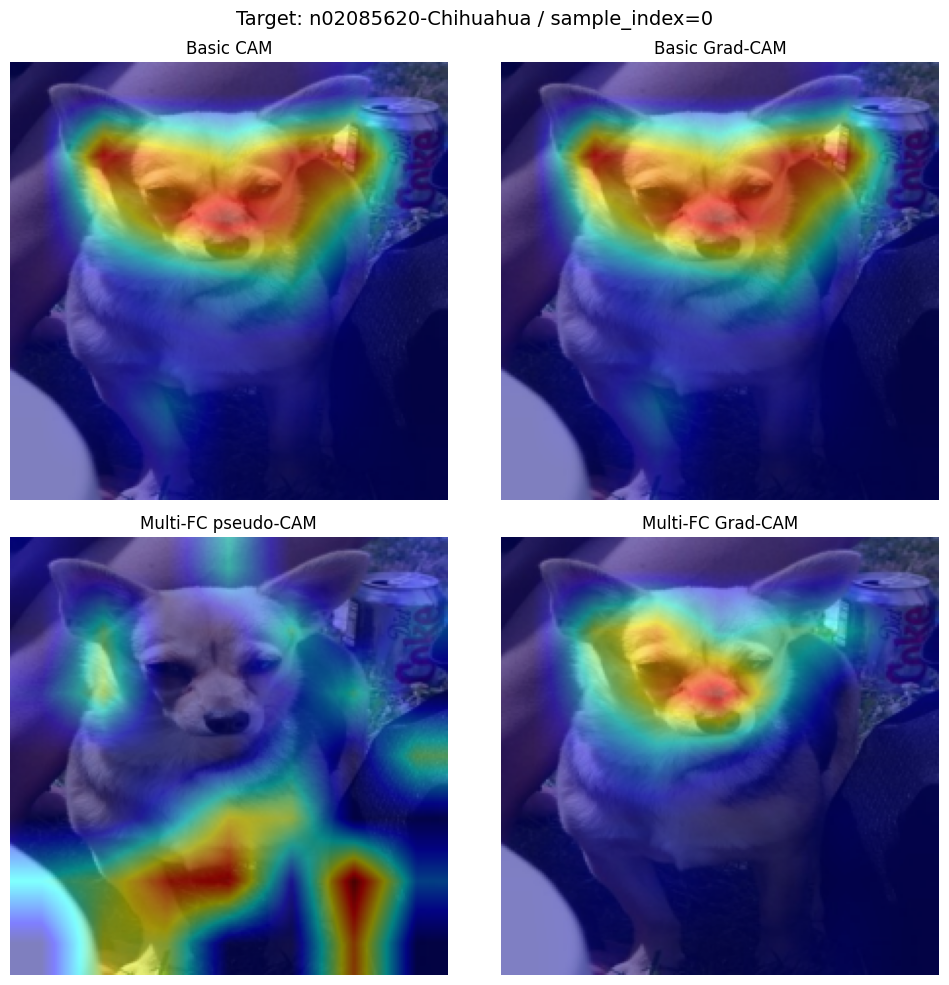

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx0.png


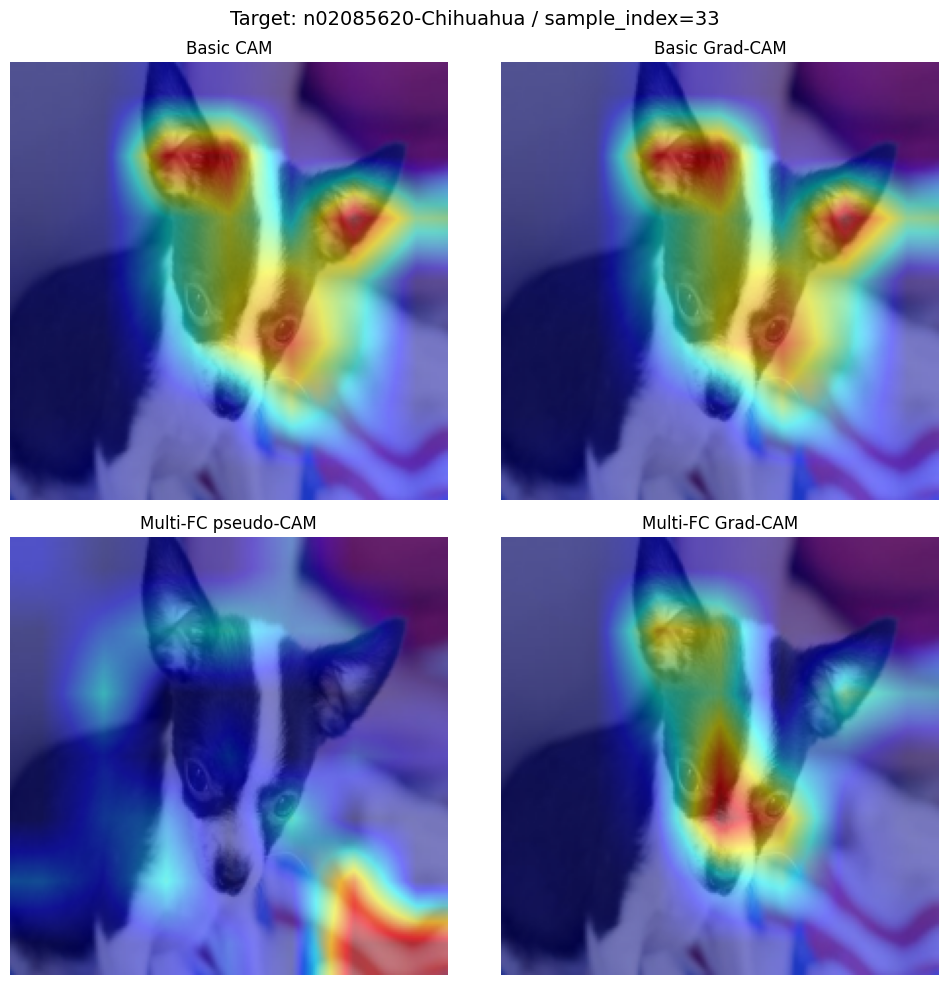

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx33.png


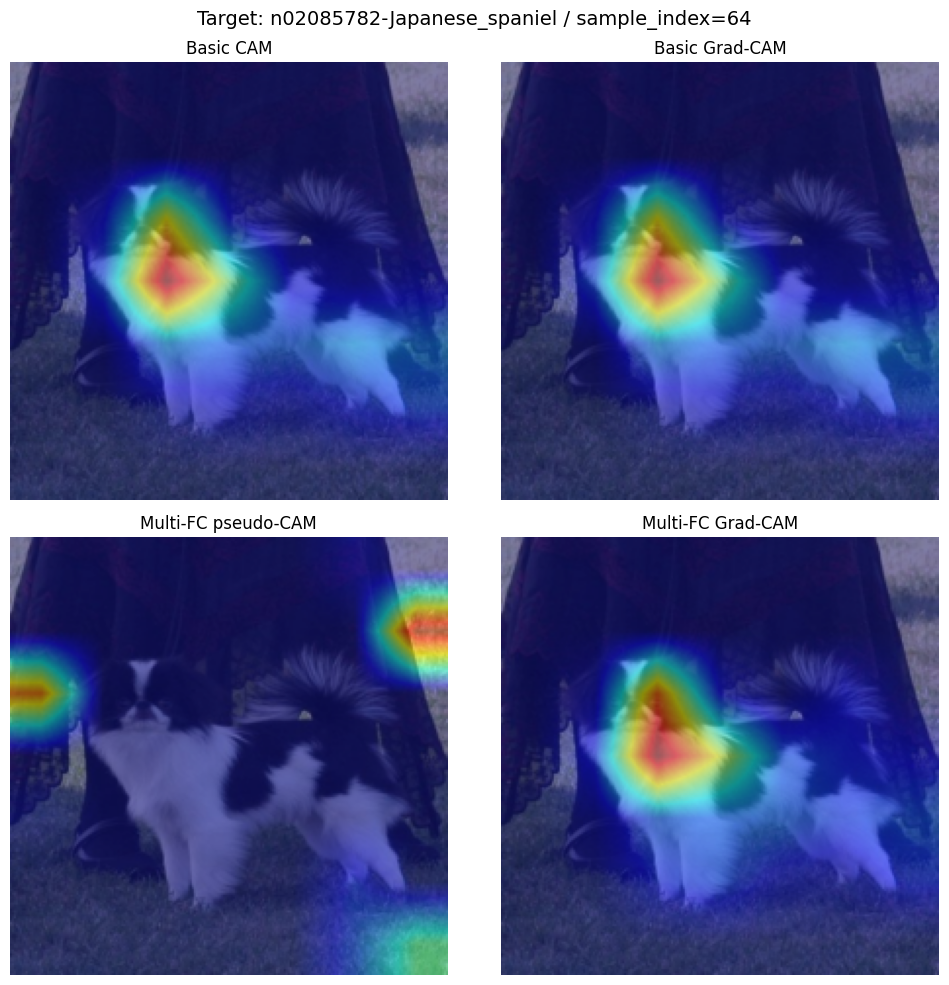

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx64.png


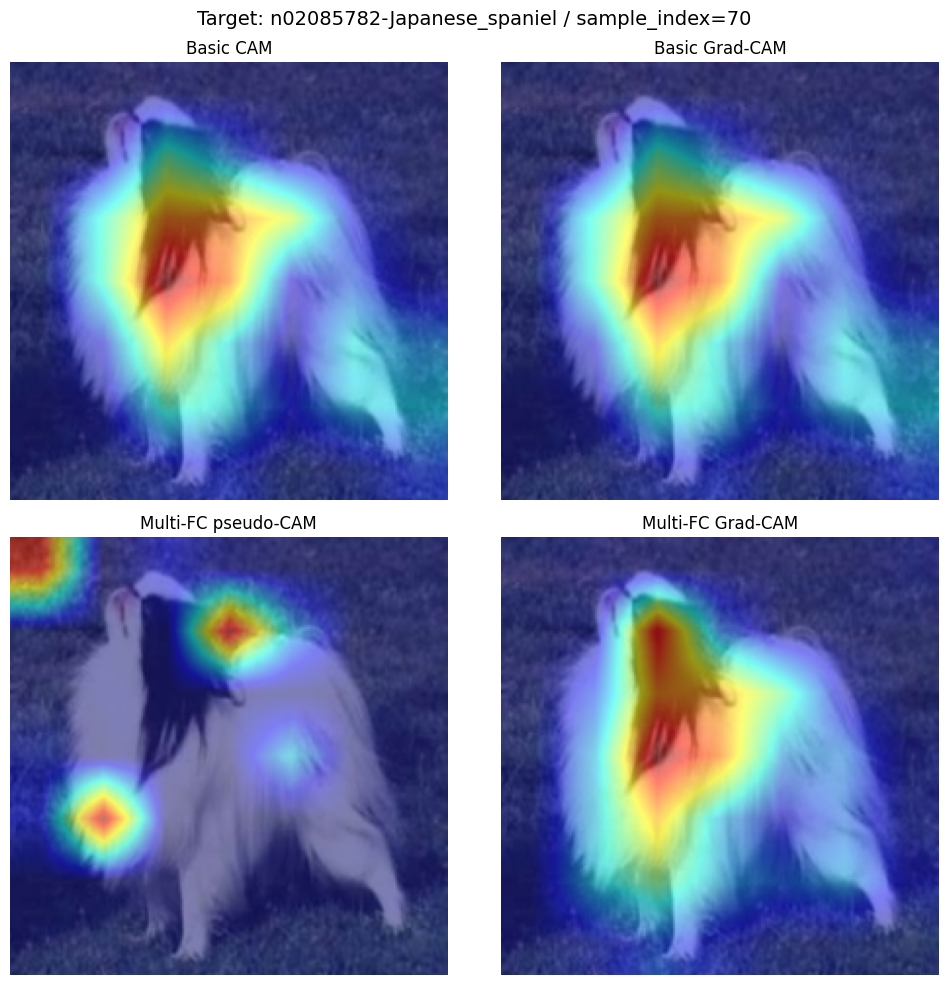

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx70.png


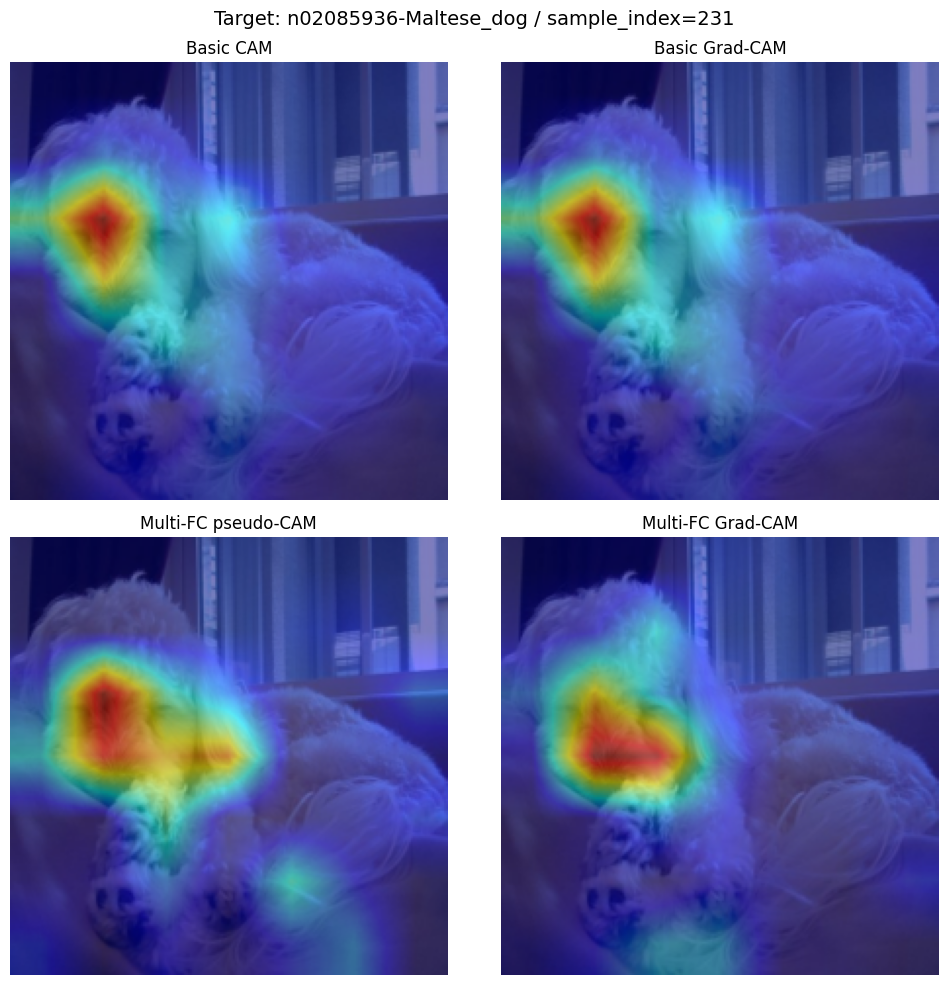

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx231.png


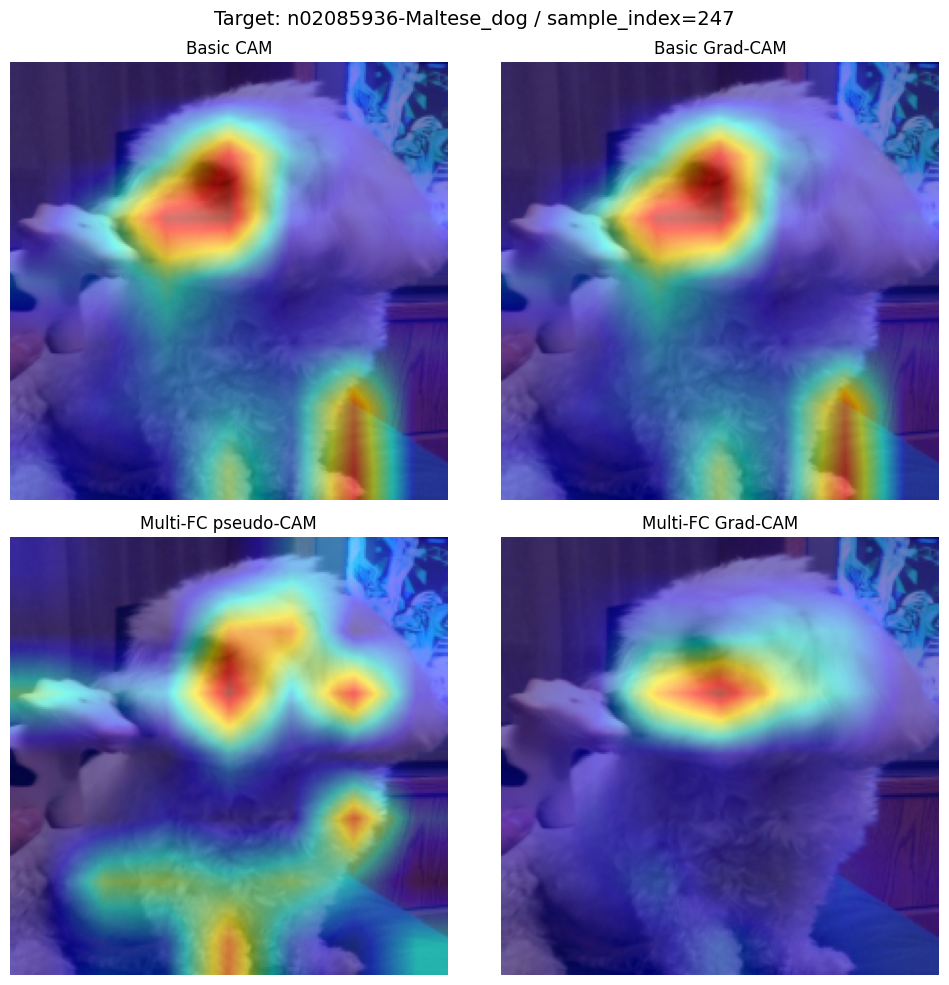

Saved comparison image: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_cam_gradcam_comparison_idx247.png


In [14]:
sample_indices = [0, 33, 64, 70, 231, 247]

for idx in sample_indices:
    create_comparison_for_sample(idx)

Energy inside bbox 정량 평가

annotation bbox를 이용해 heatmap 반응이 실제 object 영역 안에 얼마나 들어가는지 계산합니다.

계산식은 다음과 같습니다.

`Energy inside bbox = sum(H(x, y) for (x, y) in bbox) / sum(H(x, y) for all x, y)`

여기서 `H(x, y)`는 CAM 또는 Grad-CAM heatmap 값입니다. heatmap은 원래 `7x7`이므로 bbox 좌표와 맞추기 위해 원본 입력 이미지 크기인 `224x224`로 resize한 뒤 계산합니다.

주의할 점은 이 값이 classification accuracy가 아니라 localization 성격의 지표라는 것입니다. 값이 높을수록 heatmap 반응이 annotation bbox 내부에 더 집중되어 있다는 뜻입니다.

In [17]:
ENERGY_CSV = OUTPUT_DIR / "exp_energy_inside_bbox.csv"
ENERGY_PLOT_PATH = OUTPUT_DIR / "exp_energy_inside_bbox_barplot.png"


def clip_bbox_to_image(bbox, image_shape):
    """bbox를 이미지 범위 안의 정수 좌표로 clipping합니다."""
    height, width = image_shape[:2]
    xmin, ymin, xmax, ymax = bbox
    xmin = int(np.floor(max(0, min(width, xmin))))
    ymin = int(np.floor(max(0, min(height, ymin))))
    xmax = int(np.ceil(max(0, min(width, xmax))))
    ymax = int(np.ceil(max(0, min(height, ymax))))

    if xmax <= xmin or ymax <= ymin:
        return None
    return xmin, ymin, xmax, ymax


def energy_inside_bbox(heatmap, bbox, image_shape, eps=1e-8):
    """전체 heatmap energy 중 bbox 내부에 들어간 비율을 계산합니다."""
    height, width = image_shape[:2]

    # CAM/Grad-CAM은 7x7이므로 annotation bbox와 같은 224x224 좌표계로 맞춥니다.
    heatmap_resized = cv2.resize(heatmap, (width, height), interpolation=cv2.INTER_LINEAR)
    heatmap_resized = np.maximum(heatmap_resized, 0)

    clipped_bbox = clip_bbox_to_image(bbox, image_shape)
    total_energy = float(heatmap_resized.sum())
    if clipped_bbox is None or total_energy <= eps:
        return 0.0, 0.0, total_energy, clipped_bbox

    xmin, ymin, xmax, ymax = clipped_bbox
    bbox_energy = float(heatmap_resized[ymin:ymax, xmin:xmax].sum())
    ratio = bbox_energy / (total_energy + eps)
    return ratio, bbox_energy, total_energy, clipped_bbox


def get_all_heatmaps_for_sample(sample_index):
    """한 샘플에 대해 4종 heatmap과 bbox 정보를 함께 반환합니다."""
    image_tensor, label, bbox = valid_dataset[sample_index]
    target_class = int(label)
    sample_image = image_tensor.unsqueeze(0).to(device)
    orig_img = unnormalize(image_tensor)
    class_name = valid_dataset.classes[target_class]

    heatmaps = {
        "Basic CAM": generate_basic_cam(basic_model, sample_image, target_class),
        "Basic Grad-CAM": generate_grad_cam(basic_model, sample_image, target_class),
        "Multi-FC pseudo-CAM": generate_pseudo_cam_multi_fc(multi_fc_model, sample_image, target_class),
        "Multi-FC Grad-CAM": generate_grad_cam(multi_fc_model, sample_image, target_class),
    }
    return heatmaps, orig_img, bbox, target_class, class_name


def evaluate_energy_inside_bbox(sample_indices):
    """sample_indices에 대해 4종 heatmap의 bbox 내부 energy 비율을 계산하고 CSV로 저장합니다."""
    rows = []
    for sample_index in sample_indices:
        heatmaps, orig_img, bbox, target_class, class_name = get_all_heatmaps_for_sample(sample_index)

        for method, heatmap in heatmaps.items():
            ratio, bbox_energy, total_energy, clipped_bbox = energy_inside_bbox(
                heatmap=heatmap,
                bbox=bbox,
                image_shape=orig_img.shape,
            )

            if clipped_bbox is None:
                xmin = ymin = xmax = ymax = None
            else:
                xmin, ymin, xmax, ymax = clipped_bbox

            rows.append({
                "sample_index": sample_index,
                "class_index": target_class,
                "class_name": class_name,
                "method": method,
                "energy_inside_bbox": ratio,
                "bbox_energy": bbox_energy,
                "total_energy": total_energy,
                "bbox_xmin": xmin,
                "bbox_ymin": ymin,
                "bbox_xmax": xmax,
                "bbox_ymax": ymax,
            })

    fieldnames = [
        "sample_index",
        "class_index",
        "class_name",
        "method",
        "energy_inside_bbox",
        "bbox_energy",
        "total_energy",
        "bbox_xmin",
        "bbox_ymin",
        "bbox_xmax",
        "bbox_ymax",
    ]
    with open(ENERGY_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved energy metric CSV: {ENERGY_CSV}")
    return rows


def summarize_energy_rows(rows):
    """method별 평균과 표준편차를 출력합니다."""
    methods = [
        "Basic CAM",
        "Basic Grad-CAM",
        "Multi-FC pseudo-CAM",
        "Multi-FC Grad-CAM",
    ]
    for method in methods:
        values = np.array([r["energy_inside_bbox"] for r in rows if r["method"] == method], dtype=float)
        if len(values) == 0:
            continue
        print(f"{method:22s} mean={values.mean():.4f}, std={values.std():.4f}, n={len(values)}")


def plot_energy_inside_bbox(rows):
    """샘플별 energy inside bbox를 4개 방법으로 비교하는 bar plot을 저장합니다."""
    methods = [
        "Basic CAM",
        "Basic Grad-CAM",
        "Multi-FC pseudo-CAM",
        "Multi-FC Grad-CAM",
    ]
    sample_ids = sorted({r["sample_index"] for r in rows})
    x = np.arange(len(sample_ids))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 5))
    for offset, method in enumerate(methods):
        values = []
        for sample_index in sample_ids:
            matched = [
                r["energy_inside_bbox"]
                for r in rows
                if r["sample_index"] == sample_index and r["method"] == method
            ]
            values.append(matched[0] if matched else 0.0)
        ax.bar(x + (offset - 1.5) * width, values, width=width, label=method)

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in sample_ids])
    ax.set_ylim(0, 1)
    ax.set_xlabel("sample index")
    ax.set_ylabel("energy inside bbox")
    ax.set_title("Energy inside bbox by CAM method")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(ENERGY_PLOT_PATH, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved energy metric plot: {ENERGY_PLOT_PATH}")


Saved energy metric CSV: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_energy_inside_bbox.csv
Basic CAM              mean=0.9623, std=0.0248, n=6
Basic Grad-CAM         mean=0.9623, std=0.0248, n=6
Multi-FC pseudo-CAM    mean=0.7784, std=0.2673, n=6
Multi-FC Grad-CAM      mean=0.9658, std=0.0232, n=6


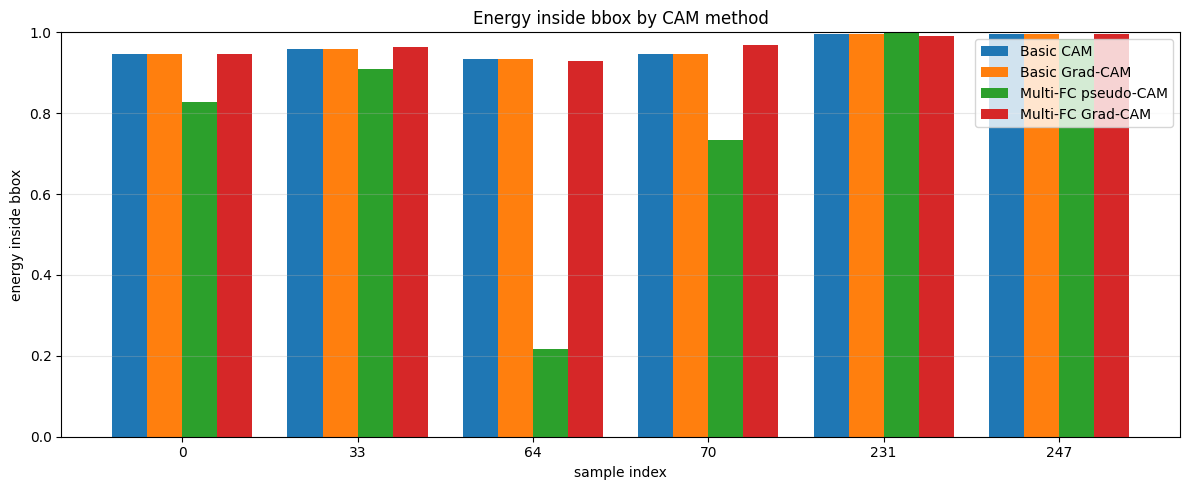

Saved energy metric plot: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_energy_inside_bbox_barplot.png


In [18]:
# 위에서 비교 이미지에 사용한 sample_indices를 그대로 재사용합니다.
energy_rows = evaluate_energy_inside_bbox(sample_indices)
summarize_energy_rows(energy_rows)
plot_energy_inside_bbox(energy_rows)


## 14. 전체/부분 샘플 평균 Energy inside bbox

위의 `sample_indices` 예시 이미지 목록과 별개로, `valid_dataset` 전체 또는 일부 샘플을 새로 뽑아 method별 평균 `energy_inside_bbox`를 계산합니다.

- `EVAL_MAX_SAMPLES = 100`: 검증 데이터에서 100개를 seed 고정 random subset으로 평가
- `EVAL_MAX_SAMPLES = 1000`: 1000개 평가
- `EVAL_MAX_SAMPLES = None`: `valid_dataset` 전체 평가

이 블록은 `bbox_energy`의 평균이 아니라, 전체 heatmap energy로 normalize된 비율인 `energy_inside_bbox`의 평균을 비교합니다.

In [19]:
EVAL_MAX_SAMPLES = 100  # None이면 valid_dataset 전체, 1000이면 1000개 평가
EVAL_RANDOM_SEED = 42

ENERGY_MEAN_CSV = OUTPUT_DIR / "exp_energy_inside_bbox_mean_eval.csv"
ENERGY_MEAN_PLOT_PATH = OUTPUT_DIR / "exp_energy_inside_bbox_mean_barplot.png"


def make_eval_indices(dataset_size, max_samples=None, seed=42):
    """전체 또는 seed 고정 일부 index를 만듭니다."""
    if max_samples is None or max_samples >= dataset_size:
        return list(range(dataset_size))

    rng = np.random.default_rng(seed)
    indices = rng.choice(dataset_size, size=max_samples, replace=False)
    return sorted(indices.tolist())


def evaluate_energy_inside_bbox_auto(max_samples=100, seed=42):
    """sample_indices와 독립적으로 valid_dataset에서 평가할 index를 정해 energy metric을 계산합니다."""
    eval_indices = make_eval_indices(len(valid_dataset), max_samples=max_samples, seed=seed)
    print(f"Evaluate samples: {len(eval_indices)} / {len(valid_dataset)}")

    rows = evaluate_energy_inside_bbox(eval_indices)

    with open(ENERGY_MEAN_CSV, "w", newline="", encoding="utf-8") as f:
        fieldnames = [
            "sample_index",
            "class_index",
            "class_name",
            "method",
            "energy_inside_bbox",
            "bbox_energy",
            "total_energy",
            "bbox_xmin",
            "bbox_ymin",
            "bbox_xmax",
            "bbox_ymax",
        ]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved full/subset energy CSV: {ENERGY_MEAN_CSV}")
    return rows


def plot_mean_energy_inside_bbox(rows):
    """method별 평균 energy inside bbox를 막대그래프로 저장하고 출력합니다."""
    methods = [
        "Basic CAM",
        "Basic Grad-CAM",
        "Multi-FC pseudo-CAM",
        "Multi-FC Grad-CAM",
    ]

    means = []
    stds = []
    counts = []

    for method in methods:
        values = np.array(
            [r["energy_inside_bbox"] for r in rows if r["method"] == method],
            dtype=float,
        )
        means.append(values.mean())
        stds.append(values.std())
        counts.append(len(values))

    x = np.arange(len(methods))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x, means, yerr=stds, capsize=5)

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("mean energy inside bbox")
    ax.set_title(f"Mean energy inside bbox (n={counts[0]})")
    ax.grid(axis="y", alpha=0.3)

    for i, mean_value in enumerate(means):
        ax.text(i, mean_value + 0.02, f"{mean_value:.3f}", ha="center")

    plt.tight_layout()
    plt.savefig(ENERGY_MEAN_PLOT_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved mean energy plot: {ENERGY_MEAN_PLOT_PATH}")

    for method, mean_value, std_value, count in zip(methods, means, stds, counts):
        print(f"{method:22s} mean={mean_value:.4f}, std={std_value:.4f}, n={count}")


Evaluate samples: 100 / 8580
Saved energy metric CSV: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_energy_inside_bbox.csv
Saved full/subset energy CSV: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_energy_inside_bbox_mean_eval.csv


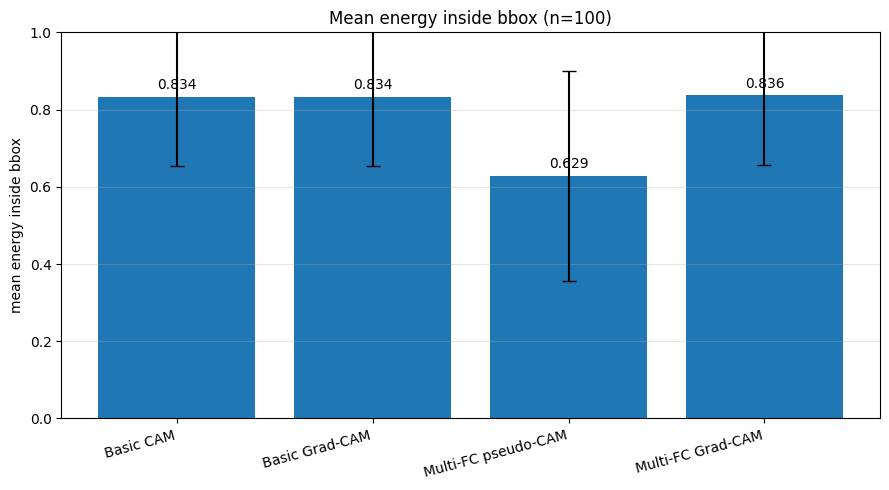

Saved mean energy plot: /home/thkim0/github/AIFFEL_quest_rs/GoingDeeper/Sp01/outputs/exp_energy_inside_bbox_mean_barplot.png
Basic CAM              mean=0.8338, std=0.1796, n=100
Basic Grad-CAM         mean=0.8338, std=0.1796, n=100
Multi-FC pseudo-CAM    mean=0.6285, std=0.2713, n=100
Multi-FC Grad-CAM      mean=0.8365, std=0.1793, n=100


In [20]:
energy_mean_rows = evaluate_energy_inside_bbox_auto(
    max_samples=EVAL_MAX_SAMPLES,
    seed=EVAL_RANDOM_SEED,
)
plot_mean_energy_inside_bbox(energy_mean_rows)


해석 정리

### Basic CAM

Basic 모델은 `Conv5 -> GAP -> FC` 구조이므로 FC weight가 Conv5 feature map의 channel과 직접 연결됩니다. 따라서 `target class`의 FC weight를 channel별 중요도로 사용해 CAM을 만들 수 있습니다.

### Basic Grad-CAM

Basic Grad-CAM은 FC weight 대신 target class score가 `layer4` feature map에 대해 가지는 gradient를 사용합니다. CAM과 같은 target layer를 보지만, weight를 얻는 방식이 다릅니다.

### Multi-FC pseudo-CAM

Multi-FC 모델의 마지막 FC weight는 Conv5 channel에 직접 연결된 weight가 아닙니다. `GAP` 이후 `FC(2048->2048) -> ReLU`를 지난 hidden feature에 대한 weight입니다. 그래서 마지막 FC weight를 Conv5 feature map에 곱하는 pseudo-CAM은 shape만 맞을 뿐, feature map channel의 class contribution을 올바르게 나타내지 못합니다.

### Multi-FC Grad-CAM

Grad-CAM은 target class score에서 target layer feature map으로 내려오는 gradient를 사용합니다. 따라서 classifier head가 단순 FC가 아니어도 적용할 수 있습니다. 이 점에서 Grad-CAM은 CAM보다 구조적으로 더 범용적인 시각화 방법입니다.

--- 